all 125 days
收盘价 $202.19 


,Close,High,Low,Open,Volume
Date,,,,,
2025-12-11,180.709579,181.099119,176.404832,180.060377,182136600
2025-12-12,174.806793,182.597294,174.407271,180.889371,204274900
2025-12-15,176.075226,178.202636,174.816766,177.723225,164775600
2025-12-16,177.503494,178.272560,174.686922,176.045266,148588100
2025-12-17,170.731750,175.915430,170.102513,175.885468,222775500
...,...,...,...,...,...
2026-06-05,205.100006,214.869995,204.330002,214.529999,219655500
2026-06-08,208.639999,210.470001,206.000000,210.179993,138372800
2026-06-09,208.190002,211.399994,199.339996,210.619995,180962500


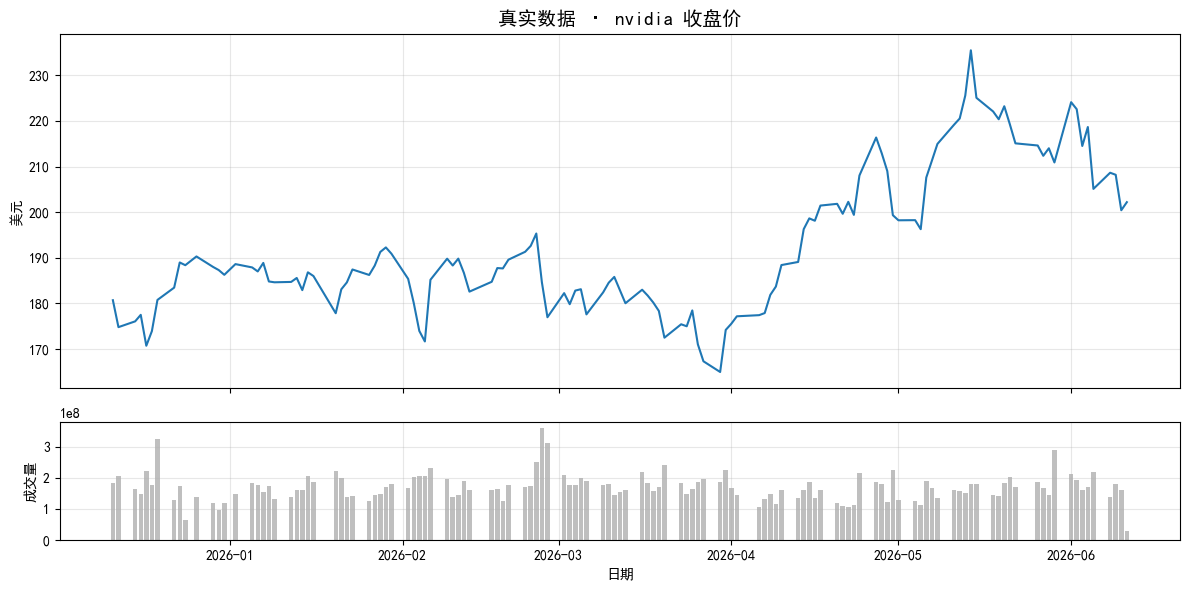

In [14]:
# 第一次实验

import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

nvda = yf.download('NVDA', period='6mo', progress=False, multi_level_index=False)

print(f'all {len(nvda)} days')
print(f'收盘价 ${nvda["Close"].iloc[-1]:.2f} ')
display(nvda)

fig, axes = plt.subplots(2,1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})

axes[0].plot(nvda.index, nvda['Close'], color='tab:blue', linewidth=1.5)
axes[0].set_title('真实数据 · nvidia 收盘价', fontsize=14)
axes[0].set_ylabel('美元')
axes[0].grid(True, alpha=0.3)

axes[1].bar(nvda.index, nvda['Volume'], width=0.8, color='gray',alpha=0.5)
axes[1].set_ylabel('成交量')
axes[1].set_xlabel('日期')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# 2 量化实验
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib
# 在命令行运行(非Jupyter)时自动切到非交互后端，避免 plt.show() 报错
if 'ipykernel' not in sys.modules and 'IPython' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import akshare as ak
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 黑体；Mac 可改 PingFang SC
plt.rcParams['axes.unicode_minus'] = False     # 负号正常显示

# 图片输出目录
try:
    # 脚本环境
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Notebook 环境，回退到当前工作目录
    base_dir = os.getcwd()
IMG_DIR = os.path.join(os.path.dirname(base_dir), 'images')
os.makedirs(IMG_DIR, exist_ok=True)
img_counter = 0


def show_or_save(title="figure"):
    """根据运行环境自动选择显示或保存图片。
    在 Jupyter 中 → plt.show() 直接显示
    在命令行中 → 保存到 images/ 目录
    """
    global img_counter
    img_counter += 1
    in_interactive = ('ipykernel' in sys.modules) or ('IPython' in sys.modules)
    if in_interactive:
        plt.show()
    else:
        fname = f"{img_counter:02d}_{title}.png"
        fpath = os.path.join(IMG_DIR, fname)
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
        print(f'  [图片已保存] {fpath}')
    plt.close()

print(f'akshare 版本: {ak.__version__}')
print('=' * 60)

# ============================================================
# 第0部分：多数据源适配 —— 自动选择可用的数据源
# ============================================================
print('0. 检测可用数据源...')
print('-' * 40)


def get_a_stock_daily(symbol, start_date, end_date, adjust="hfq"):
    """
    获取A股日线数据，自动选择可用数据源。

    参数:
        symbol:   股票代码，如 "600519"（不需要 sh/sz 前缀）
        start_date: 开始日期 "YYYYMMDD"
        end_date:   结束日期 "YYYYMMDD"
        adjust:     复权方式 "hfq"(后复权,推荐) / "qfq"(前复权) / ""(不复权)

    返回:
        DataFrame，列名统一为: date/open/high/low/close/volume
    """
    # 方案A：东方财富（推荐首选，数据质量高）
    try:
        df = ak.stock_zh_a_hist(
            symbol=symbol, period="daily",
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        df = df.rename(columns={
            '日期': 'date', '开盘': 'open', '收盘': 'close',
            '最高': 'high', '最低': 'low', '成交量': 'volume'
        })
        print(f'  [东方财富] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案B：新浪（需要 sh/sz 前缀）
    try:
        prefix = 'sh' if symbol.startswith(('6', '9')) else 'sz'
        df = ak.stock_zh_a_daily(
            symbol=f'{prefix}{symbol}',
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        df = df.rename(columns={
            'date': 'date', 'open': 'open', 'close': 'close',
            'high': 'high', 'low': 'low', 'volume': 'volume'
        })
        print(f'  [新浪] {prefix}{symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案C：腾讯（sz/sh 前缀格式，注意列名可能不同）
    try:
        prefix = 'sh' if symbol.startswith(('6', '9')) else 'sz'
        df = ak.stock_zh_a_hist_tx(
            symbol=f'{prefix}{symbol}',
            start_date=start_date, end_date=end_date, adjust=adjust
        )
        # 腾讯源可能返回不同的列名，统一映射
        col_map = {}
        for c in df.columns:
            if c in ('日期', 'date'): col_map[c] = 'date'
            elif c in ('开盘', 'open'): col_map[c] = 'open'
            elif c in ('收盘', 'close'): col_map[c] = 'close'
            elif c in ('最高', 'high'): col_map[c] = 'high'
            elif c in ('最低', 'low'): col_map[c] = 'low'
            elif c in ('成交量', 'volume'): col_map[c] = 'volume'
            elif c in ('成交额', 'amount'): col_map[c] = 'amount'
        df = df.rename(columns=col_map)
        if 'volume' not in df.columns and 'amount' in df.columns:
            df['volume'] = 0
        print(f'  [腾讯] {prefix}{symbol}: {len(df)} 天')
        return df
    except Exception as e:
        raise RuntimeError(f'所有数据源均不可用！最后错误: {e}')


def get_index_daily(symbol):
    """
    获取指数日线，自动选择可用数据源。

    参数:
        symbol: 指数代码，如 "sh000001"(上证) / "sz399001"(深证) / "sh000300"(沪深300)
    """
    # 方案A：新浪（老牌，稳定）
    try:
        df = ak.stock_zh_index_daily(symbol=symbol)
        print(f'  [新浪] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案B：腾讯
    try:
        df = ak.stock_zh_index_daily_tx(symbol=symbol)
        print(f'  [腾讯] {symbol}: {len(df)} 天')
        return df
    except Exception:
        pass

    # 方案C：东方财富
    try:
        df = ak.stock_zh_index_daily_em(symbol=symbol)
        print(f'  [东方财富] {symbol}: {len(df)} 天')
        return df
    except Exception as e:
        raise RuntimeError(f'所有数据源均不可用！最后错误: {e}')

df_test = get_a_stock_daily("600522","20240101","20260615", adjust="hfq")
print(f'列名{df_test.columns.tolist()}')
display(df_test.head())
display(df_test.tail(10))

print('环境就绪 ✓')



akshare 版本: 1.18.64
0. 检测可用数据源...
----------------------------------------
  [新浪] sh600522: 591 天
列名['date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'outstanding_share', 'turnover']


,date,open,high,low,close,volume,amount,outstanding_share,turnover
0,2024-01-02,108.45,109.32,107.41,107.50,32238516.0,401725385.0,3.412950e+09,0.009446
1,2024-01-03,107.24,108.45,105.33,106.63,33397744.0,411139419.0,3.412950e+09,0.009786
2,2024-01-04,106.54,106.54,104.29,104.98,24776117.0,300169387.0,3.412950e+09,0.007259
3,2024-01-05,104.98,105.42,101.34,101.69,42451030.0,503787154.0,3.412950e+09,0.012438
4,2024-01-08,101.60,102.90,99.87,99.96,30188955.0,352702491.0,3.412950e+09,0.008845


,date,open,high,low,close,volume,amount,outstanding_share,turnover
581,2026-06-02,350.67,389.31,350.67,385.35,405978244.0,1.706939e+10,3.412950e+09,0.118952
582,2026-06-03,394.34,422.10,389.94,404.13,419182256.0,1.896276e+10,3.412950e+09,0.122821
583,2026-06-04,393.62,423.90,393.62,413.83,354368175.0,1.627420e+10,3.412950e+09,0.103830
584,2026-06-05,405.03,443.57,403.86,413.92,406564804.0,1.920093e+10,3.412950e+09,0.119124
585,2026-06-08,395.33,455.34,395.33,445.01,513156539.0,2.520513e+10,3.412950e+09,0.150356
586,2026-06-09,454.00,489.49,436.30,489.49,484808226.0,2.497789e+10,3.412950e+09,0.142050
587,2026-06-10,471.70,483.29,441.87,451.03,383672432.0,1.956162e+10,3.412950e+09,0.112417
588,2026-06-11,446.45,458.22,431.71,442.68,289909172.0,1.436316e+10,3.412950e+09,0.084944
589,2026-06-12,455.70,469.00,436.57,436.66,330123533.0,1.653254e+10,3.412950e+09,0.096727
590,2026-06-15,448.96,462.44,421.20,461.36,309924242.0,1.542331e+10,3.412950e+09,0.090808


环境就绪 ✓


  [东方财富] 600522: 591 天


1     -0.007423
2     -0.014440
3     -0.029042
4     -0.015764
5     -0.006434
         ...   
586    0.097057
587   -0.076495
588   -0.017995
589   -0.013205
590    0.054926
Name: close, Length: 590, dtype: float64

(array([ 1.,  0.,  1.,  3.,  3.,  1.,  1.,  2.,  8.,  8., 14., 15., 22.,
        28., 52., 68., 58., 81., 51., 28., 34., 24., 13., 13., 12., 11.,
        10.,  7.,  4.,  6.,  5.,  1.,  1.,  0.,  4.]),
 array([-0.09190274, -0.08650388, -0.08110502, -0.07570616, -0.07030729,
        -0.06490843, -0.05950957, -0.05411071, -0.04871184, -0.04331298,
        -0.03791412, -0.03251526, -0.02711639, -0.02171753, -0.01631867,
        -0.01091981, -0.00552094, -0.00012208,  0.00527678,  0.01067564,
         0.01607451,  0.02147337,  0.02687223,  0.03227109,  0.03766996,
         0.04306882,  0.04846768,  0.05386654,  0.05926541,  0.06466427,
         0.07006313,  0.07546199,  0.08086086,  0.08625972,  0.09165858,
         0.09705744]),
 <BarContainer object of 35 artists>)

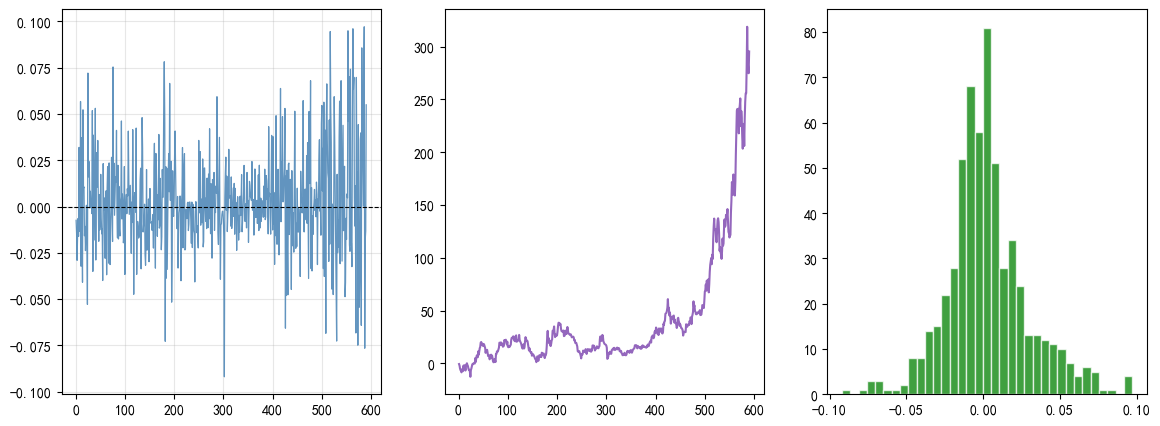

In [16]:
data  = get_a_stock_daily("600522","20240101","20260615", adjust="hfq")

df = data['close'].pct_change().dropna()
display(df)

rets = df
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].plot(rets.index, rets.values, color='steelblue',linewidth=0.9, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

cum_return = (1 + rets).cumprod()-1
axes[1].plot(cum_return.index, cum_return.values*100, color='tab:purple', linewidth=1.5)

axes[2].hist(rets.values, bins=35, color='green', alpha=0.75, edgecolor='white')
